In [1]:
import matplotlib.pyplot as plt
import numpy as np
import json
import awkward as ak
import correctionlib 

In [2]:
with open("electron.json", "r") as f:
    data = json.load(f)
print(data.keys())
for corr in data["corrections"]:
    print(corr["name"])
corr = next(
    c for c in data["corrections"]
    if c["name"] == "Electron-ID-SF"
)
print(corr["data"].keys())
print(corr["data"]["input"])
for item in corr["data"]["content"]:
    print(item["key"])
year_node = next(
    item
    for item in corr["data"]["content"]
    if item["key"] == "2024Prompt"
)

print(year_node.keys())

print(year_node["value"].keys())

valtype_node = year_node["value"]

print(valtype_node["input"])

for item in valtype_node["content"]:
    print(item["key"])

sf_node = next(
    item
    for item in valtype_node["content"]
    if item["key"] == "sf"
)

print(sf_node.keys())
print(sf_node["value"]["input"])

working_point_node = sf_node["value"]

for item in working_point_node["content"]:
    print(item["key"])

wp90_node = next(
    item
    for item in working_point_node["content"]
    if item["key"] == "wp80iso"
)

print(wp90_node.keys())
print(wp90_node["value"].keys())

table = wp90_node["value"]

print(table["inputs"])

print("eta edges:")
print(table["edges"][0])

print("\npt edges:")
print(table["edges"][1])

eta_edges = table["edges"][0]
pt_edges = table["edges"][1]

n_eta = len(eta_edges) - 1
n_pt = len(pt_edges) - 1

print("Number of eta bins:", n_eta)
print("Number of pt bins :", n_pt)

print("Number of SF values:", len(table["content"]))
print("Expected           :", n_eta * n_pt)

import numpy as np

sf = np.array(table["content"])

sf = sf.reshape(n_eta, n_pt)

print(sf.shape)
print(sf)

import pandas as pd

rows = []

for i in range(n_eta):
    for j in range(n_pt):

        rows.append({
            "eta_min": eta_edges[i],
            "eta_max": eta_edges[i + 1],
            "pt_min": pt_edges[j],
            "pt_max": pt_edges[j + 1],
            "SF": sf[i, j],
        })

df = pd.DataFrame(rows)

print(df)

print(table["inputs"])
print(table["edges"][0])
print(table["edges"][1])

print(len(table["content"]))

dict_keys(['schema_version', 'description', 'corrections'])
Electron-ID-SF
dict_keys(['nodetype', 'input', 'content'])
year
2024Prompt
dict_keys(['key', 'value'])
dict_keys(['nodetype', 'input', 'content'])
ValType
sf
sfup
sfdown
effMC
effData
err_statMC
err_statData
err_stat
err_syst
dict_keys(['key', 'value'])
WorkingPoint
RecoBelow20
Reco20to75
RecoAbove75
Veto
Loose
Medium
Tight
wp80iso
wp90iso
wp80noiso
wp90noiso
PromptMVA-Medium
PromptMVA-Tight
dict_keys(['key', 'value'])
dict_keys(['nodetype', 'inputs', 'edges', 'content', 'flow'])
['eta', 'pt']
eta edges:
['-inf', -2.0, -1.566, -1.444, -0.8, 0.0, 0.8, 1.444, 1.566, 2.0, 'inf']

pt edges:
[10.0, 20.0, 35.0, 50.0, 70.0, 100.0, 200.0, 300.0, 500.0, 700.0, 1000.0, 'inf']
Number of eta bins: 10
Number of pt bins : 11
Number of SF values: 110
Expected           : 110
(10, 11)
[[0.85974824 0.88142699 0.88576859 0.87068319 0.91699809 0.91118467
  0.91506094 0.91506094 0.91506094 0.91506094 1.        ]
 [0.94684231 0.93442035 0.94050008

In [3]:
def plot_electron_sf(
    json_file,
    working_point="wp90iso",
    year="2024Prompt",
    valtype="sf",
):
    """
    Plot an electron SF map from a correctionlib JSON without using correctionlib.

    Parameters
    ----------
    json_file : str
        Path to the electron JSON file.

    working_point : str
        Working point to plot, e.g.
        "wp90iso", "wp80iso", "Loose", "Medium", "Tight",
        "RecoBelow20", "Reco20to75", "RecoAbove75".

    year : str
        Year/era in the JSON, e.g. "2024Prompt".

    valtype : str
        Correction type:
        "sf", "sfup", "sfdown", "effMC", "effData", etc.
    """

    # ------------------------------------------------------------
    # Load JSON
    # ------------------------------------------------------------

    with open(json_file, "r") as f:
        data = json.load(f)

    # ------------------------------------------------------------
    # Find Electron-ID-SF correction
    # ------------------------------------------------------------

    corr = next(
        c for c in data["corrections"]
        if c["name"] == "Electron-ID-SF"
    )

    # ------------------------------------------------------------
    # Select year
    # ------------------------------------------------------------

    year_node = next(
        item
        for item in corr["data"]["content"]
        if item["key"] == year
    )

    # ------------------------------------------------------------
    # Select ValType
    # ------------------------------------------------------------

    valtype_node = year_node["value"]

    sf_node = next(
        item
        for item in valtype_node["content"]
        if item["key"] == valtype
    )

    # ------------------------------------------------------------
    # Select working point
    # ------------------------------------------------------------

    working_point_node = sf_node["value"]

    available_wps = [
        item["key"]
        for item in working_point_node["content"]
    ]

    if working_point not in available_wps:
        raise ValueError(
            f"Working point '{working_point}' not found.\n"
            f"Available working points:\n"
            + "\n".join(f"  {wp}" for wp in available_wps)
        )

    wp_node = next(
        item
        for item in working_point_node["content"]
        if item["key"] == working_point
    )

    # ------------------------------------------------------------
    # Extract table
    # ------------------------------------------------------------

    table = wp_node["value"]

    if table["nodetype"] != "multibinning":
        raise ValueError(
            f"'{working_point}' is not a multibinning table."
        )

    print("Working point :", working_point)
    print("Year          :", year)
    print("ValType       :", valtype)
    print("Inputs        :", table["inputs"])

    # ------------------------------------------------------------
    # Get eta and pT edges
    # ------------------------------------------------------------

    eta_edges = table["edges"][0]
    pt_edges = table["edges"][1]

    n_eta = len(eta_edges) - 1
    n_pt = len(pt_edges) - 1

    # ------------------------------------------------------------
    # Get SF values
    # ------------------------------------------------------------

    sf = np.array(table["content"])

    expected = n_eta * n_pt

    if len(sf) != expected:
        raise ValueError(
            f"Number of values ({len(sf)}) does not match "
            f"number of bins ({expected})."
        )

    sf = sf.reshape(n_eta, n_pt)

    # ------------------------------------------------------------
    # Print information
    # ------------------------------------------------------------

    print("Number of eta bins:", n_eta)
    print("Number of pt bins :", n_pt)
    print("SF range          :", sf.min(), "to", sf.max())

    # ------------------------------------------------------------
    # Convert edges for plotting
    # ------------------------------------------------------------

    eta_edges = np.array(eta_edges, dtype=float)
    pt_edges = np.array(pt_edges, dtype=float)

    # Replace infinities only for visualization
    eta_edges_plot = eta_edges.copy()
    pt_edges_plot = pt_edges.copy()

    eta_edges_plot[0] = -2.5
    eta_edges_plot[-1] = 2.5

    # pt_edges_plot[0] = 10
    pt_edges_plot[-1] = 1100

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------

    fig, ax = plt.subplots(figsize=(14, 8))

    mesh = ax.pcolormesh(
        pt_edges_plot,
        eta_edges_plot,
        sf,
        shading="flat",
    )

    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label("Electron SF")

    # ------------------------------------------------------------
    # Put SF value on every cell
    # ------------------------------------------------------------

    for i in range(n_eta):
        for j in range(n_pt):

            x_center = (
                pt_edges_plot[j]
                + pt_edges_plot[j + 1]
            ) / 2

            y_center = (
                eta_edges_plot[i]
                + eta_edges_plot[i + 1]
            ) / 2

            ax.text(
                x_center,
                y_center,
                f"{sf[i, j]:.3f}",
                ha="center",
                va="center",
                fontsize=8,
            )

    # ------------------------------------------------------------
    # Axis labels
    # ------------------------------------------------------------

    ax.set_xlabel("Electron $p_T$ [GeV]")
    ax.set_ylabel("Electron $\eta$")

    ax.set_title(
        f"{year} — Electron {working_point} SF"
    )

    ax.set_xscale("log")

    plt.tight_layout()
    plt.show()

    return sf, eta_edges, pt_edges

Working point : Reco20to75
Year          : 2024Prompt
ValType       : sf
Inputs        : ['eta', 'pt']
Number of eta bins: 12
Number of pt bins : 3
SF range          : 0.9535102248191833 to 1.0075559616088867


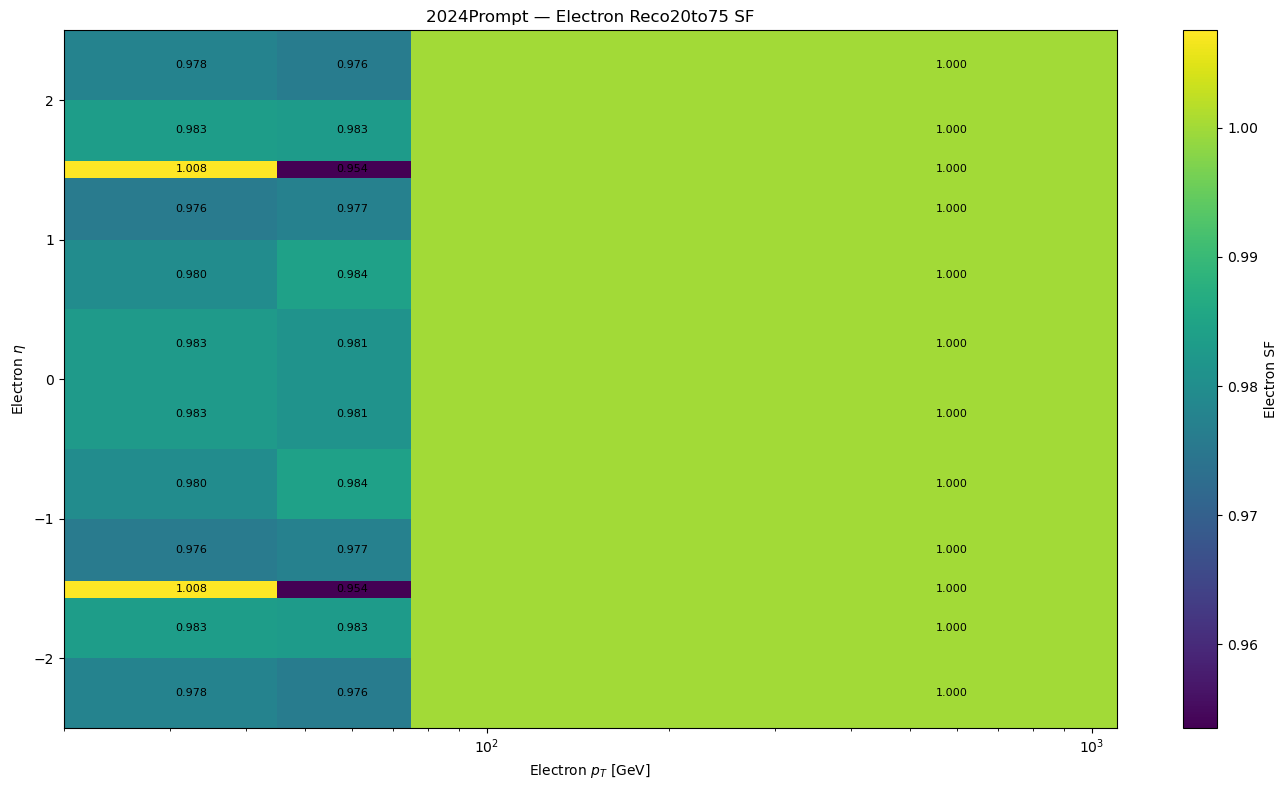

(array([[0.97777277, 0.9760772 , 1.        ],
        [0.98328149, 0.98304558, 1.        ],
        [1.00755596, 0.95351022, 1.        ],
        [0.97579056, 0.97700101, 1.        ],
        [0.97956091, 0.9841333 , 1.        ],
        [0.98279345, 0.98136747, 1.        ],
        [0.98279345, 0.98136747, 1.        ],
        [0.97956091, 0.9841333 , 1.        ],
        [0.97579056, 0.97700101, 1.        ],
        [1.00755596, 0.95351022, 1.        ],
        [0.98328149, 0.98304558, 1.        ],
        [0.97777277, 0.9760772 , 1.        ]]),
 array([  -inf, -2.   , -1.566, -1.444, -1.   , -0.5  ,  0.   ,  0.5  ,
         1.   ,  1.444,  1.566,  2.   ,    inf]),
 array([20., 45., 75., inf]))

In [4]:
plot_electron_sf(
    "electron.json",
    working_point="Reco20to75",
)

Working point : RecoAbove75
Year          : 2024Prompt
ValType       : sf
Inputs        : ['eta', 'pt']
Number of eta bins: 12
Number of pt bins : 3
SF range          : 0.9716854095458984 to 1.0543994903564453


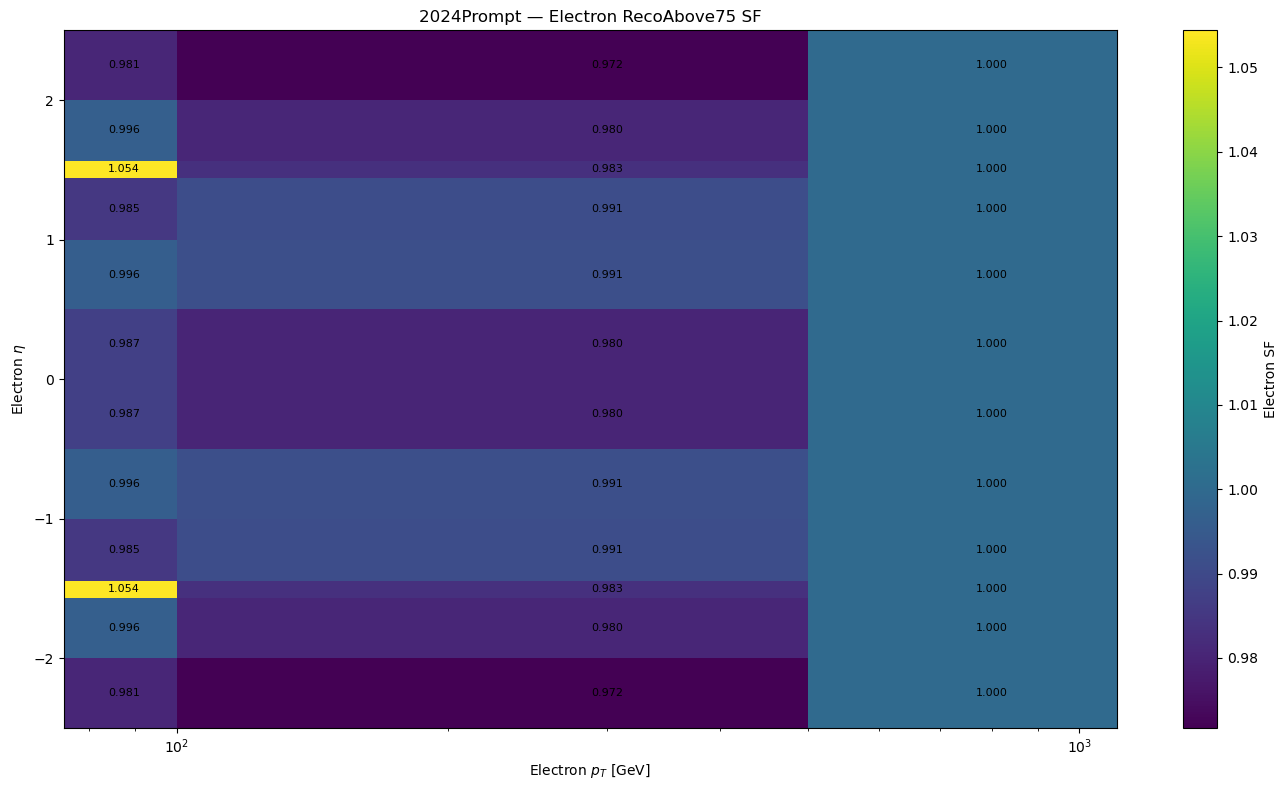

(array([[0.9805848 , 0.97168541, 1.        ],
        [0.99646431, 0.98044491, 1.        ],
        [1.05439949, 0.98314106, 1.        ],
        [0.98508233, 0.99093115, 1.        ],
        [0.99596435, 0.99149376, 1.        ],
        [0.98743474, 0.98011446, 1.        ],
        [0.98743474, 0.98011446, 1.        ],
        [0.99596435, 0.99149376, 1.        ],
        [0.98508233, 0.99093115, 1.        ],
        [1.05439949, 0.98314106, 1.        ],
        [0.99646431, 0.98044491, 1.        ],
        [0.9805848 , 0.97168541, 1.        ]]),
 array([  -inf, -2.   , -1.566, -1.444, -1.   , -0.5  ,  0.   ,  0.5  ,
         1.   ,  1.444,  1.566,  2.   ,    inf]),
 array([ 75., 100., 500.,  inf]))

In [5]:
plot_electron_sf(
    "electron.json",
    working_point="RecoAbove75",
)

Working point : wp80iso
Year          : 2024Prompt
ValType       : sf
Inputs        : ['eta', 'pt']
Number of eta bins: 10
Number of pt bins : 11
SF range          : 0.8371437788009644 to 1.0


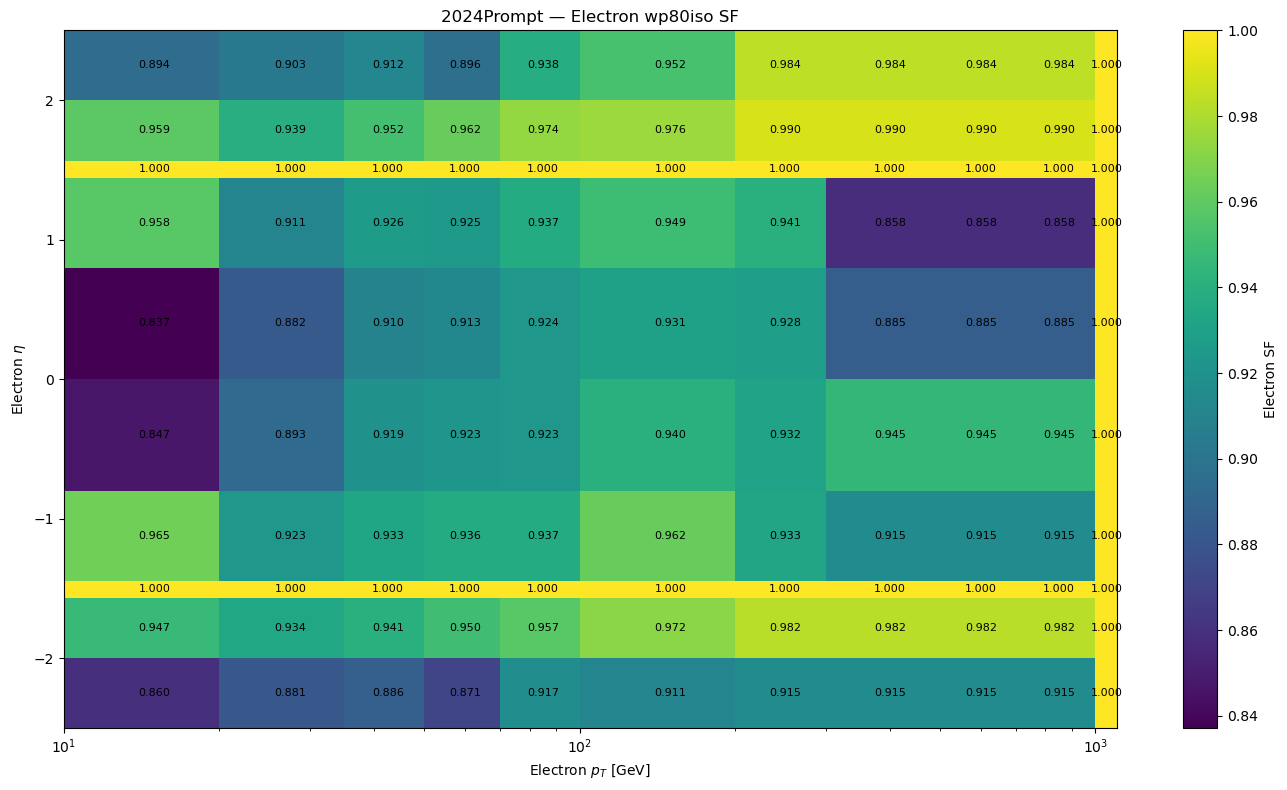

(array([[0.85974824, 0.88142699, 0.88576859, 0.87068319, 0.91699809,
         0.91118467, 0.91506094, 0.91506094, 0.91506094, 0.91506094,
         1.        ],
        [0.94684231, 0.93442035, 0.94050008, 0.95020622, 0.95739323,
         0.97178483, 0.9824636 , 0.9824636 , 0.9824636 , 0.9824636 ,
         1.        ],
        [1.        , 1.        , 1.        , 1.        , 1.        ,
         1.        , 1.        , 1.        , 1.        , 1.        ,
         1.        ],
        [0.96455598, 0.92304033, 0.93346375, 0.93641716, 0.93694866,
         0.96243298, 0.93274081, 0.91497111, 0.91497111, 0.91497111,
         1.        ],
        [0.84695953, 0.89253235, 0.91862965, 0.92270994, 0.92345047,
         0.94025475, 0.93186843, 0.94519961, 0.94519961, 0.94519961,
         1.        ],
        [0.83714378, 0.88240612, 0.91019237, 0.91294605, 0.92387468,
         0.9306407 , 0.92809445, 0.88521564, 0.88521564, 0.88521564,
         1.        ],
        [0.95779282, 0.91109812, 0.92647

In [6]:
plot_electron_sf(
    "electron.json",
    working_point="wp80iso",
)

In [7]:
def plot_electron_HLT_sf(
    json_file,
    SForEff,
    working_point="HLT_SF_Ele30_MVAiso80ID",
    year="2024Prompt",
    valtype="sf"
):
    """
    Plot an electron SF map from a correctionlib JSON without using correctionlib.

    Parameters
    ----------
    json_file : str
        Path to the electron JSON file.

    working_point : str
        Working point to plot, e.g.
            "HLT_SF_Ele30_LooseID"
            "HLT_SF_Ele30_MediumID"
            "HLT_SF_Ele30_TightID"
            "HLT_SF_Ele30_MVAiso90ID"
            "HLT_SF_Ele30_MVAiso80ID"

    year : str
        Year/era in the JSON, e.g. "2024Prompt".

    valtype : str
        Correction type:
        "sf"
        "sfup"
        "sfdown"
        "nom",
        "up",
        "down"
    """

    endtxt = None

    if SForEff == "Electron-HLT-DataEff":
        endtxt = "DataEff"
    if SForEff == "Electron-HLT-McEff":
        endtxt = "McEff"
    if SForEff == "Electron-HLT-SF":
        endtxt = "SF"


    # ------------------------------------------------------------
    # Load JSON
    # ------------------------------------------------------------

    with open(json_file, "r") as f:
        data = json.load(f)

    # ------------------------------------------------------------
    # Find Electron-ID-SF correction
    # ------------------------------------------------------------

    corr = next(
        c for c in data["corrections"]
        if c["name"] == SForEff
    )

    # ------------------------------------------------------------
    # Select year
    # ------------------------------------------------------------

    year_node = next(
        item
        for item in corr["data"]["content"]
        if item["key"] == year
    )

    # ------------------------------------------------------------
    # Select ValType
    # ------------------------------------------------------------

    valtype_node = year_node["value"]

    sf_node = next(
        item
        for item in valtype_node["content"]
        if item["key"] == valtype
    )

    # ------------------------------------------------------------
    # Select working point
    # ------------------------------------------------------------

    working_point_node = sf_node["value"]

    available_wps = [
        item["key"]
        for item in working_point_node["content"]
    ]

    if working_point not in available_wps:
        raise ValueError(
            f"Working point '{working_point}' not found.\n"
            f"Available working points:\n"
            + "\n".join(f"  {wp}" for wp in available_wps)
        )

    wp_node = next(
        item
        for item in working_point_node["content"]
        if item["key"] == working_point
    )

    # ------------------------------------------------------------
    # Extract table
    # ------------------------------------------------------------

    table = wp_node["value"]

    if table["nodetype"] != "multibinning":
        raise ValueError(
            f"'{working_point}' is not a multibinning table."
        )

    print("Working point :", working_point)
    print("Year          :", year)
    print("ValType       :", valtype)
    print("Inputs        :", table["inputs"])

    # ------------------------------------------------------------
    # Get eta and pT edges
    # ------------------------------------------------------------

    eta_edges = table["edges"][0]
    pt_edges = table["edges"][1]

    n_eta = len(eta_edges) - 1
    n_pt = len(pt_edges) - 1

    # ------------------------------------------------------------
    # Get SF values
    # ------------------------------------------------------------

    sf = np.array(table["content"])

    expected = n_eta * n_pt

    if len(sf) != expected:
        raise ValueError(
            f"Number of values ({len(sf)}) does not match "
            f"number of bins ({expected})."
        )

    sf = sf.reshape(n_eta, n_pt)

    # ------------------------------------------------------------
    # Print information
    # ------------------------------------------------------------

    print("Number of eta bins:", n_eta)
    print("Number of pt bins :", n_pt)
    print("SF range          :", sf.min(), "to", sf.max())

    # ------------------------------------------------------------
    # Convert edges for plotting
    # ------------------------------------------------------------

    eta_edges = np.array(eta_edges, dtype=float)
    pt_edges = np.array(pt_edges, dtype=float)

    # Replace infinities only for visualization
    eta_edges_plot = eta_edges.copy()
    pt_edges_plot = pt_edges.copy()

    eta_edges_plot[0] = -2.5
    eta_edges_plot[-1] = 2.5

    pt_edges_plot[-1] = 250

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------

    fig, ax = plt.subplots(figsize=(14, 8))

    mesh = ax.pcolormesh(
        pt_edges_plot,
        eta_edges_plot,
        sf,
        shading="flat",
    )

    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label("Electron HLT SF")

    # ------------------------------------------------------------
    # Put SF value on every cell
    # ------------------------------------------------------------

    for i in range(n_eta):
        for j in range(n_pt-1):

            x_center = (
                pt_edges_plot[j]
                + pt_edges_plot[j + 1]
            ) / 2

            y_center = (
                eta_edges_plot[i]
                + eta_edges_plot[i + 1]
            ) / 2

            ax.text(
                x_center,
                y_center,
                f"{sf[i, j]:.3f}",
                ha="center",
                va="center",
                fontsize=8,
            )

    # ------------------------------------------------------------
    # Axis labels
    # ------------------------------------------------------------

    ax.set_xlabel("Electron $p_T$ [GeV]")
    ax.set_ylabel("Electron $\eta$")

    ax.set_title(
        f"{year} — Electron {working_point} {endtxt}"
    )

    ax.set_xscale("log")

    plt.tight_layout()
    plt.show()

    return sf, eta_edges, pt_edges

Working point : HLT_SF_Ele30_MVAiso80ID
Year          : 2024Prompt
ValType       : sf
Inputs        : ['eta', 'pt']
Number of eta bins: 10
Number of pt bins : 10
SF range          : 0.47842949628829956 to 1.8526616096496582


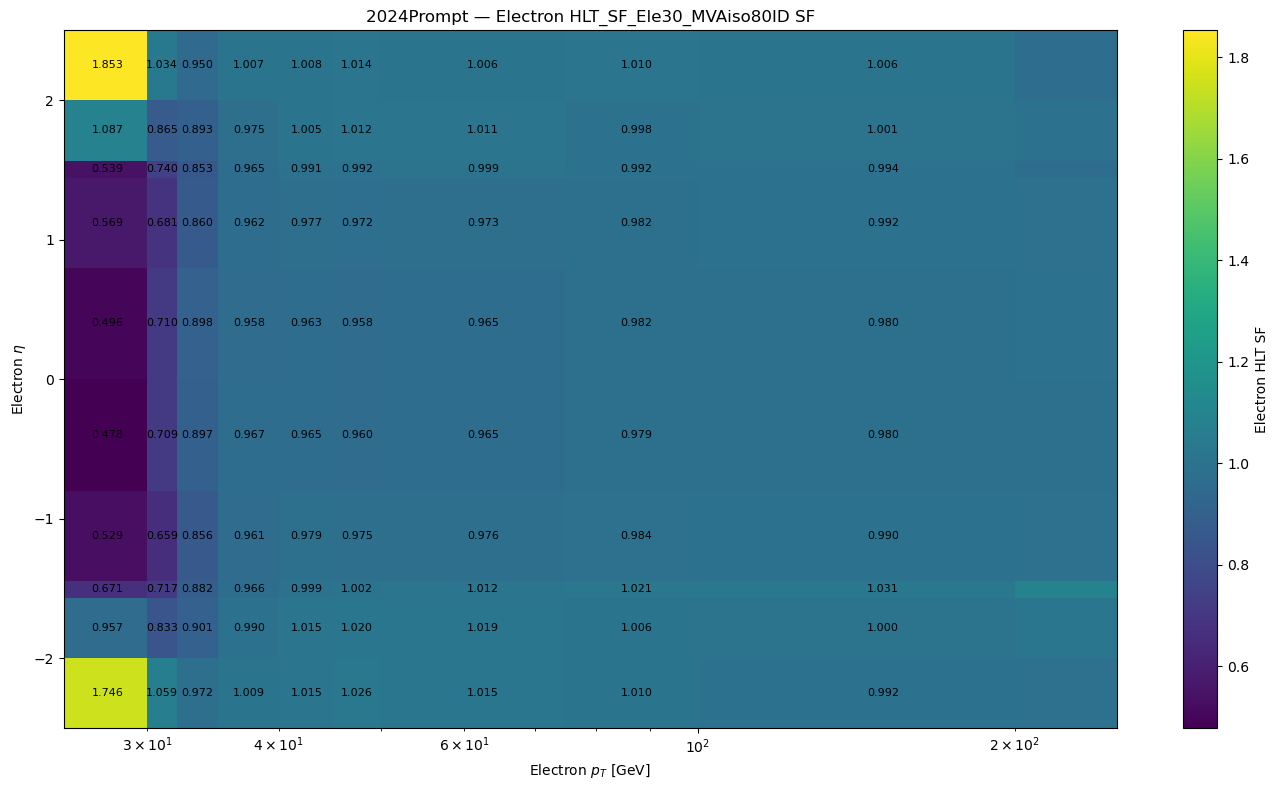

(array([[1.74629402, 1.05927753, 0.97237206, 1.00920963, 1.01461244,
         1.02614772, 1.01542461, 1.00959253, 0.9923768 , 0.98816603],
        [0.95701241, 0.83347183, 0.90067524, 0.99027503, 1.01517224,
         1.02034307, 1.01908326, 1.00628674, 1.00023222, 1.01898611],
        [0.67149687, 0.71739715, 0.88176733, 0.96643198, 0.99881518,
         1.00163722, 1.01236475, 1.02066827, 1.03099895, 1.09531116],
        [0.528741  , 0.65907681, 0.85627264, 0.96144378, 0.97898495,
         0.97502923, 0.97622204, 0.98367405, 0.98992413, 0.98507512],
        [0.4784295 , 0.70943809, 0.89681065, 0.96651804, 0.96520841,
         0.95982617, 0.96451116, 0.97917873, 0.97974271, 0.98125994],
        [0.49614909, 0.70993978, 0.89798242, 0.95848435, 0.9631058 ,
         0.95836174, 0.96453506, 0.98239368, 0.98048443, 0.98850489],
        [0.56938678, 0.68134218, 0.86016667, 0.96215308, 0.9767459 ,
         0.97181547, 0.97271872, 0.98179942, 0.99163222, 0.98679751],
        [0.53890795, 0.7396

In [8]:
plot_electron_HLT_sf("electronHlt.json", "Electron-HLT-SF")

Working point : HLT_SF_Ele30_MVAiso80ID
Year          : 2024Prompt
ValType       : nom
Inputs        : ['eta', 'pt']
Number of eta bins: 10
Number of pt bins : 10
SF range          : 0.01610499992966652 to 0.9637724757194519


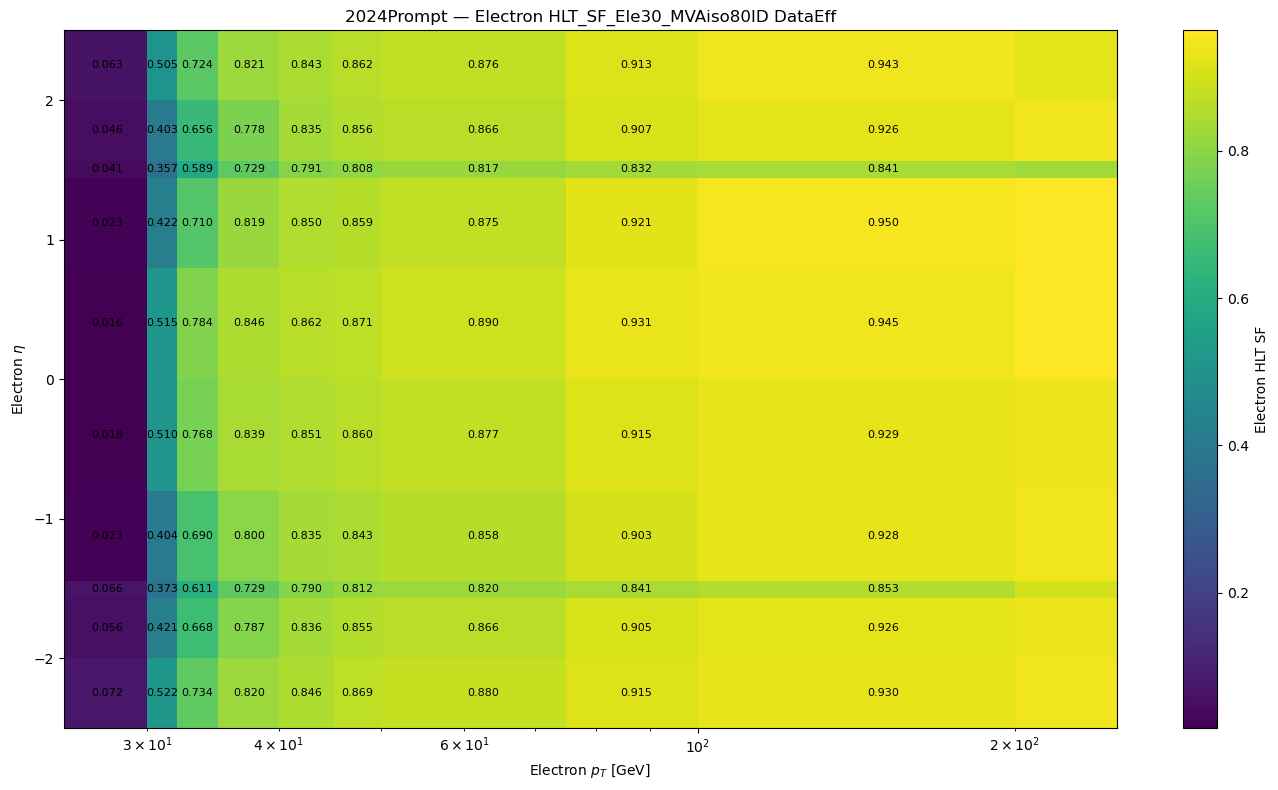

(array([[0.07186   , 0.52224499, 0.73373252, 0.81994247, 0.84606498,
         0.86857247, 0.88049501, 0.91539752, 0.930125  , 0.943995  ],
        [0.055545  , 0.421195  , 0.66760749, 0.78713   , 0.83587247,
         0.85466999, 0.866445  , 0.90476251, 0.92607498, 0.93533748],
        [0.066035  , 0.37286001, 0.61093253, 0.72947252, 0.79032248,
         0.8121475 , 0.81977248, 0.841245  , 0.85326499, 0.89936   ],
        [0.02272   , 0.4042975 , 0.68950498, 0.80045003, 0.83503503,
         0.84253252, 0.85837251, 0.90318   , 0.92769748, 0.94185001],
        [0.0175775 , 0.50971001, 0.76834249, 0.83901501, 0.85141999,
         0.86022502, 0.87716502, 0.91469002, 0.92909002, 0.94028252],
        [0.016105  , 0.51539499, 0.783795  , 0.84626502, 0.86171001,
         0.87111253, 0.88981253, 0.93084753, 0.9446575 , 0.96377248],
        [0.023305  , 0.42225501, 0.70963752, 0.81884998, 0.849935  ,
         0.85873502, 0.87506747, 0.92148751, 0.95012248, 0.96101248],
        [0.04086   , 0.3571

In [9]:
plot_electron_HLT_sf("electronHlt.json", "Electron-HLT-DataEff", valtype="nom")

Working point : HLT_SF_Ele30_MVAiso80ID
Year          : 2024Prompt
ValType       : nom
Inputs        : ['eta', 'pt']
Number of eta bins: 10
Number of pt bins : 10
SF range          : 0.03246000036597252 to 0.9749799966812134


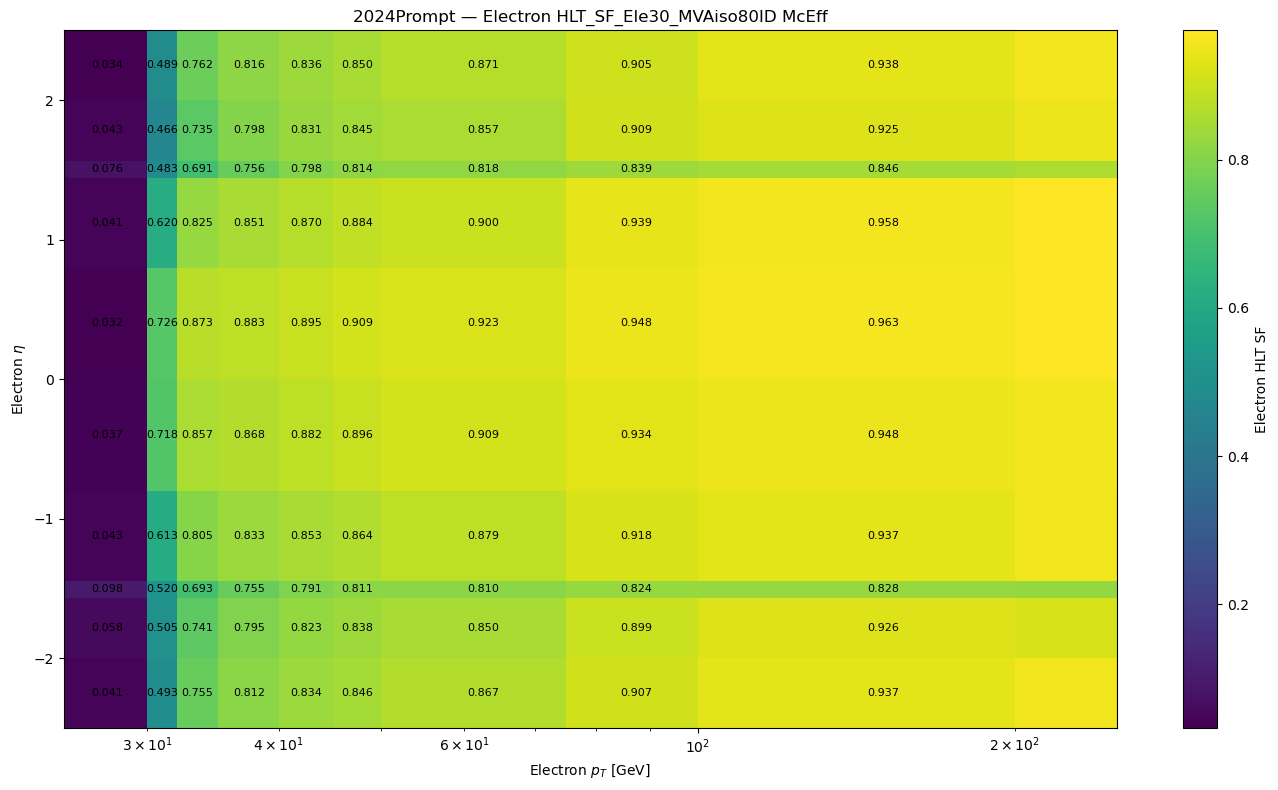

(array([[0.04115   , 0.49302   , 0.75458002, 0.81246001, 0.83388001,
         0.84644002, 0.86712003, 0.90670002, 0.93726999, 0.95529997],
        [0.05804   , 0.50534999, 0.74123001, 0.79486001, 0.82337999,
         0.83762997, 0.85022002, 0.89911002, 0.92585999, 0.91790998],
        [0.09834   , 0.51973999, 0.69284999, 0.75480998, 0.79126   ,
         0.81081998, 0.80975997, 0.82420999, 0.82761002, 0.8211    ],
        [0.04297   , 0.61343002, 0.80523998, 0.83254999, 0.85295999,
         0.86410999, 0.87927997, 0.91816998, 0.93713999, 0.95612001],
        [0.03674   , 0.71846998, 0.85675001, 0.86808002, 0.88211   ,
         0.89622998, 0.90943998, 0.93414003, 0.9483    , 0.95823997],
        [0.03246   , 0.72596997, 0.87283999, 0.88292003, 0.89472002,
         0.90895998, 0.92253   , 0.94752997, 0.96346003, 0.97498   ],
        [0.04093   , 0.61974001, 0.82499999, 0.85105997, 0.87017   ,
         0.88363999, 0.89960998, 0.93857002, 0.95814002, 0.97386998],
        [0.07582   , 0.4828

In [10]:
plot_electron_HLT_sf("electronHlt.json", "Electron-HLT-McEff", valtype="nom")

In [11]:
def plot_muon_trigger(
    json_file,
    correction_name,
    key="nominal",
):
    """
    Plot a quantity from a muon trigger correction JSON.

    Parameters
    ----------
    json_file : str
        Path to the JSON file.

    correction_name : str
        Name of the correction, e.g.
        "NUM_IsoMu24_DEN_CutBasedIdMedium_and_PFIsoMedium"

    key : str
        Quantity to plot. Available:
            "nominal"          -> trigger SF
            "nominal_DATAeff"  -> Data efficiency
            "nominal_MCeff"    -> MC efficiency
            "statup"
            "statdown"
            "systup"
            "systdown"
            etc.
    """

    # ------------------------------------------------------------
    # Load JSON
    # ------------------------------------------------------------

    with open(json_file, "r") as f:
        data = json.load(f)

    # ------------------------------------------------------------
    # Find correction
    # ------------------------------------------------------------

    corr = next(
        c for c in data["corrections"]
        if c["name"] == correction_name
    )

    table = corr["data"]

    # ------------------------------------------------------------
    # Check requested key
    # ------------------------------------------------------------

    available_keys = set()

    for eta_node in table["content"]:
        for pt_node in eta_node["content"]:
            for item in pt_node["content"]:
                available_keys.add(item["key"])

    if key not in available_keys:
        raise ValueError(
            f"Key '{key}' not found.\n"
            f"Available keys:\n"
            + "\n".join(
                f"  {k}" for k in sorted(available_keys)
            )
        )

    # ------------------------------------------------------------
    # Eta edges
    # ------------------------------------------------------------

    eta_edges = np.array(
        table["edges"],
        dtype=float
    )

    n_eta = len(eta_edges) - 1

    # ------------------------------------------------------------
    # pT edges
    # ------------------------------------------------------------

    pt_edges = np.array(
        table["content"][0]["edges"],
        dtype=float
    )

    n_pt = len(pt_edges) - 1

    # ------------------------------------------------------------
    # Extract requested quantity
    # ------------------------------------------------------------

    values = np.zeros((n_eta, n_pt))

    for i in range(n_eta):

        pt_table = table["content"][i]

        # Make sure pT binning is consistent
        current_pt_edges = np.array(
            pt_table["edges"],
            dtype=float
        )

        if not np.array_equal(
            current_pt_edges,
            pt_edges
        ):
            raise ValueError(
                "pT binning is different for different eta bins."
            )

        for j in range(n_pt):

            category = pt_table["content"][j]

            values[i, j] = next(
                item["value"]
                for item in category["content"]
                if item["key"] == key
            )

    # ------------------------------------------------------------
    # Print information
    # ------------------------------------------------------------

    print("Correction :", correction_name)
    print("Quantity   :", key)
    print("Eta bins   :", n_eta)
    print("pT bins    :", n_pt)
    print(
        "Range      :",
        values.min(),
        "to",
        values.max()
    )

    # ------------------------------------------------------------
    # Plotting edges
    # ------------------------------------------------------------

    pt_edges_plot = pt_edges.copy()

    # Last bin is 200 -> infinity.
    # Replace infinity only for visualization.
    if np.isinf(pt_edges_plot[-1]):
        pt_edges_plot[-1] = 300

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(14, 8)
    )

    mesh = ax.pcolormesh(
        pt_edges_plot,
        eta_edges,
        values,
        shading="flat",
    )

    # ------------------------------------------------------------
    # Colorbar label
    # ------------------------------------------------------------

    labels = {
        "nominal": "Muon trigger SF",
        "nominal_DATAeff": "Muon trigger Data efficiency",
        "nominal_MCeff": "Muon trigger MC efficiency",
        "statup": "Statistical uncertainty (up)",
        "statdown": "Statistical uncertainty (down)",
        "systup": "Systematic uncertainty (up)",
        "systdown": "Systematic uncertainty (down)",
    }

    cbar_label = labels.get(
        key,
        f"Muon trigger {key}"
    )

    cbar = fig.colorbar(
        mesh,
        ax=ax
    )

    cbar.set_label(cbar_label)

    # ------------------------------------------------------------
    # Put value on every cell
    # ------------------------------------------------------------

    for i in range(n_eta):

        for j in range(n_pt):

            # Geometric center for log x-axis
            x1 = pt_edges_plot[j]

            if j == n_pt - 1:
                x2 = pt_edges_plot[j] * 1.5
            else:
                x2 = pt_edges_plot[j + 1]

            x_center = np.sqrt(x1 * x2)

            y_center = (
                eta_edges[i]
                + eta_edges[i + 1]
            ) / 2

            ax.text(
                x_center,
                y_center,
                f"{values[i, j]:.3f}",
                ha="center",
                va="center",
                fontsize=8,
            )

    # ------------------------------------------------------------
    # Axis labels
    # ------------------------------------------------------------

    ax.set_xscale("log")

    ax.set_xlabel(
        "Muon $p_T$ [GeV]"
    )

    ax.set_ylabel(
        "Muon $\eta$"
    )

    ax.set_title(
        f"{correction_name}\n{cbar_label}"
    )

    plt.tight_layout()
    plt.show()

    return values, eta_edges, pt_edges

Correction : NUM_IsoMu24_DEN_CutBasedIdMedium_and_PFIsoMedium
Quantity   : nominal_MCeff
Eta bins   : 13
pT bins    : 7
Range      : 0.6926392316818237 to 0.9679988622665405


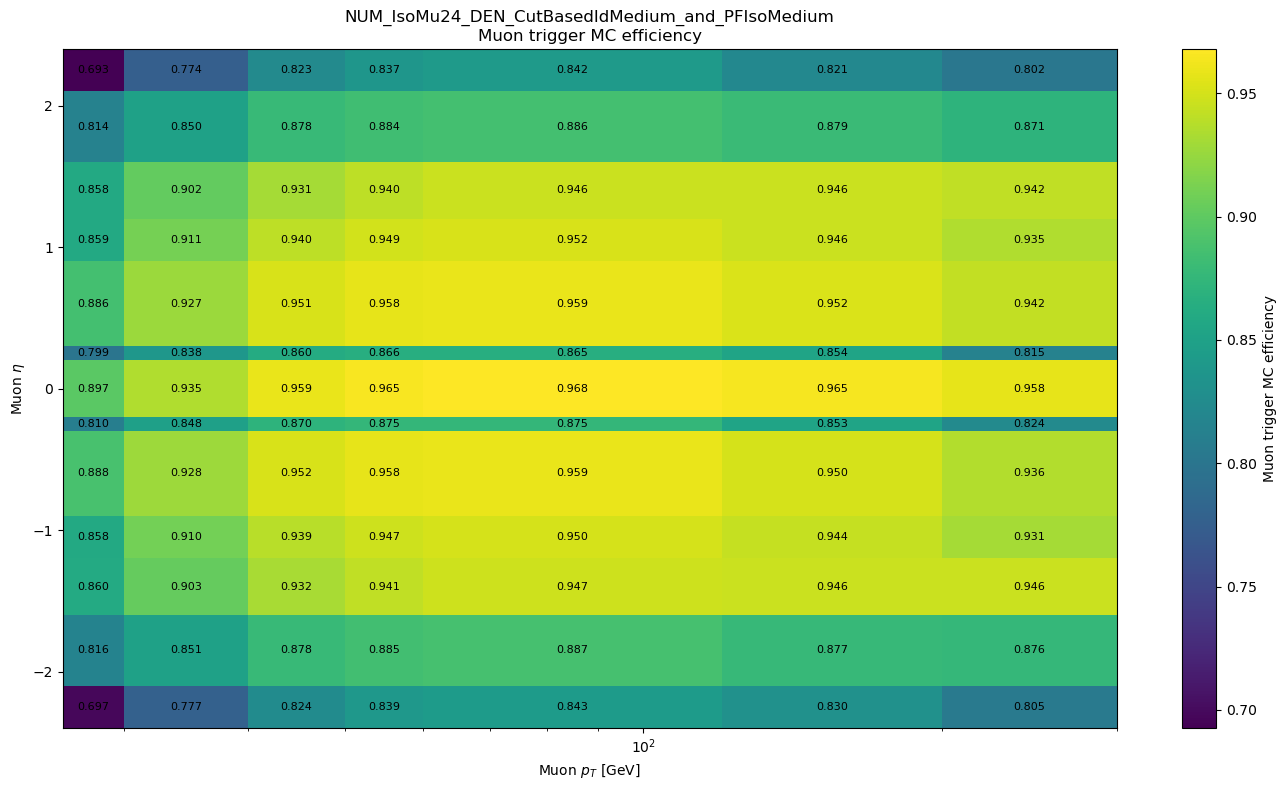

In [12]:
data_eff, _, _ = plot_muon_trigger(
    "muon_Z.json",
    "NUM_IsoMu24_DEN_CutBasedIdMedium_and_PFIsoMedium",
    key="nominal_MCeff",
)

Correction : NUM_IsoMu24_DEN_CutBasedIdMedium_and_PFIsoMedium
Quantity   : nominal_DATAeff
Eta bins   : 13
pT bins    : 7
Range      : 0.7042713761329651 to 0.9520853757858276


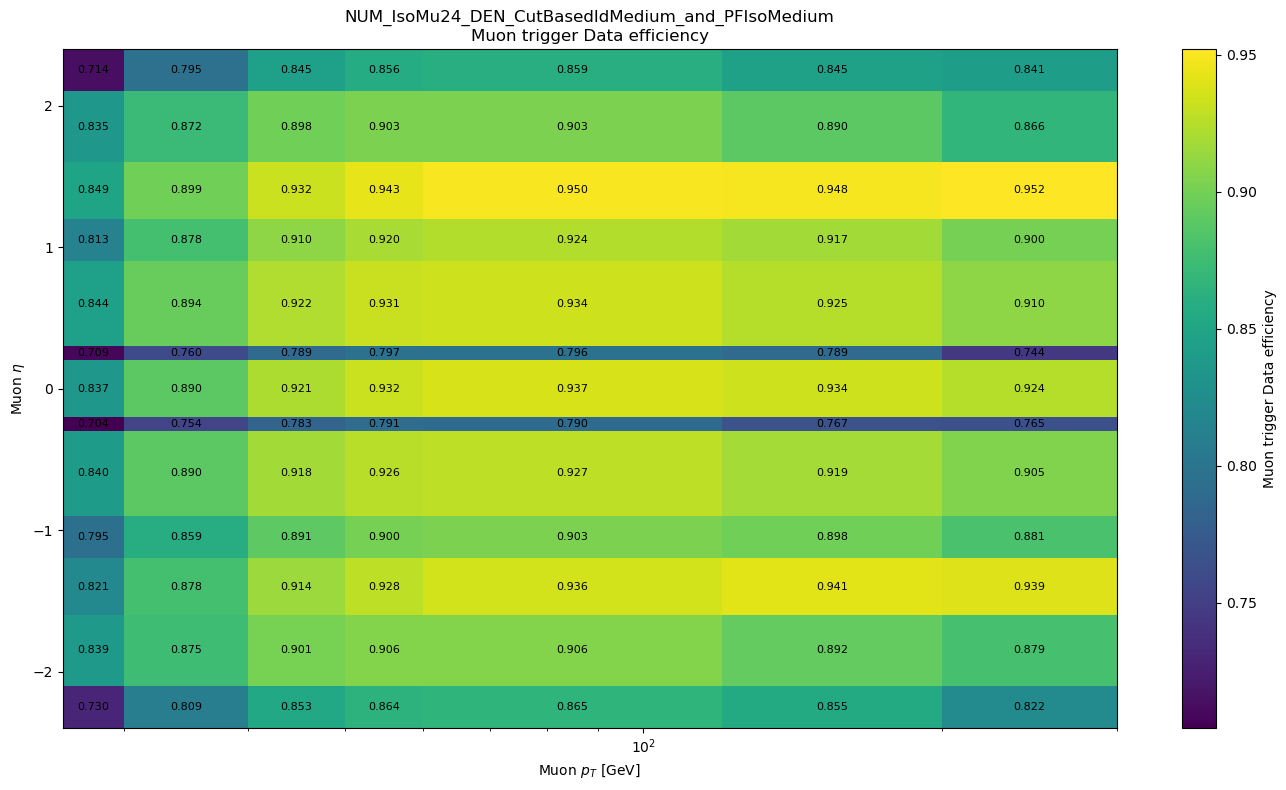

In [13]:
data_eff, _, _ = plot_muon_trigger(
    "muon_Z.json",
    "NUM_IsoMu24_DEN_CutBasedIdMedium_and_PFIsoMedium",
    key="nominal_DATAeff",
)

Correction : NUM_IsoMu24_DEN_CutBasedIdMedium_and_PFIsoMedium
Quantity   : nominal
Eta bins   : 13
pT bins    : 7
Range      : 0.8697434663772583 to 1.0492407083511353


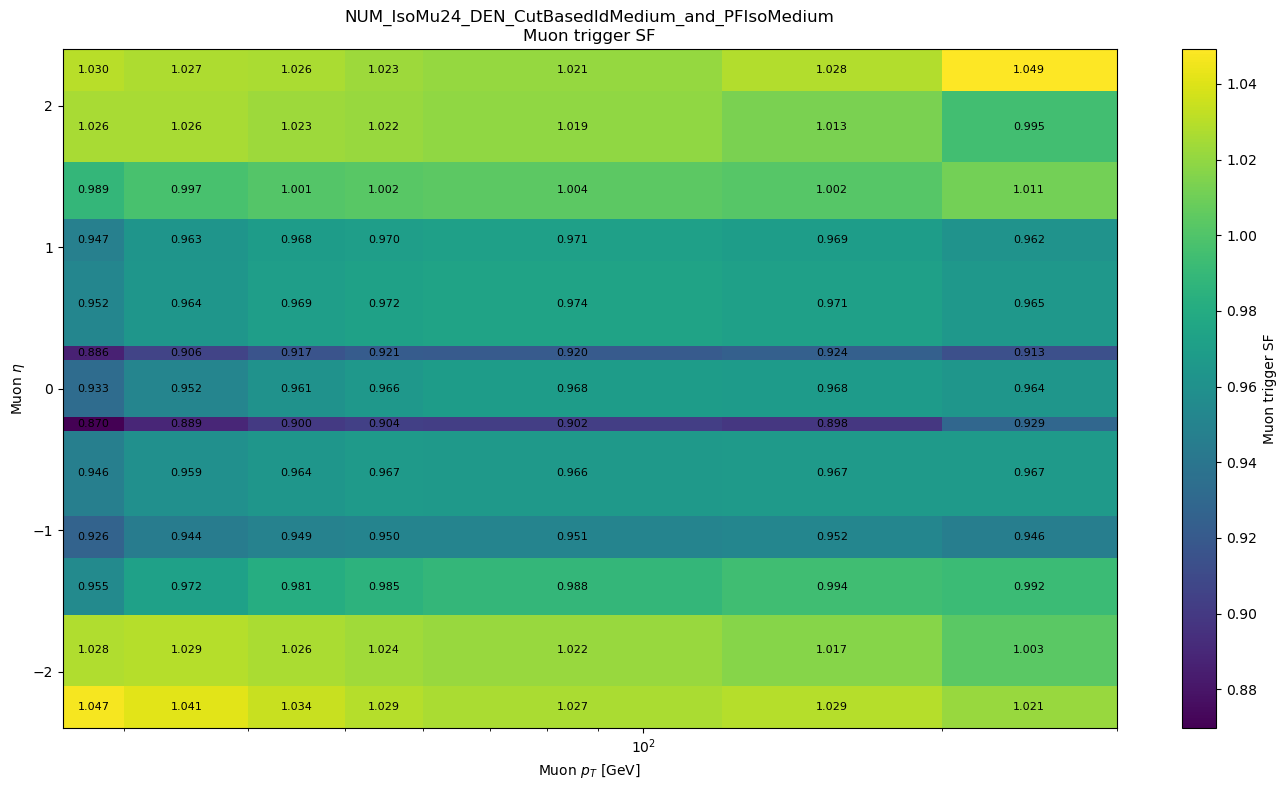

In [14]:
data_eff, _, _ = plot_muon_trigger(
    "muon_Z.json",
    "NUM_IsoMu24_DEN_CutBasedIdMedium_and_PFIsoMedium",
    key="nominal",
)

In [24]:
with open('muon_Z.json', "r") as f:
    data = json.load(f)
for k,c in enumerate(data["corrections"]):
    print(c['name'])

NUM_LooseID_DEN_TrackerMuons
NUM_MediumID_DEN_TrackerMuons
NUM_MediumPromptID_DEN_TrackerMuons
NUM_TightID_DEN_TrackerMuons
NUM_SoftID_DEN_TrackerMuons
NUM_HighPtID_DEN_TrackerMuons
NUM_TrkHighPtID_DEN_TrackerMuons
NUM_LoosePFIso_DEN_LooseID
NUM_LoosePFIso_DEN_MediumID
NUM_LoosePFIso_DEN_MediumPromptID
NUM_LoosePFIso_DEN_TightID
NUM_LooseRelTkIso_DEN_HighPtID
NUM_LooseRelTkIso_DEN_TrkHighPtID
NUM_MediumPFIso_DEN_MediumID
NUM_TightPFIso_DEN_MediumID
NUM_TightPFIso_DEN_MediumPromptID
NUM_TightPFIso_DEN_TightID
NUM_TightRelTkIso_DEN_HighPtID
NUM_TightRelTkIso_DEN_TrkHighPtID
NUM_MediumMvaMuID_DEN_TrackerMuons
NUM_TightMvaMuID_DEN_TrackerMuons
NUM_LooseMiniIso_DEN_LooseID
NUM_LooseMiniIso_DEN_MediumID
NUM_MediumMiniIso_DEN_MediumID
NUM_TightMiniIso_DEN_MediumID
NUM_promptMVA_WP64ID_DEN_MediumID
NUM_promptMVA_WP64ID_DEN_TightID
NUM_TightMiniIso_DEN_TightID
NUM_IsoMu24_or_Mu50_or_CascadeMu100_or_HighPtTkMu100_DEN_CutBasedIdMedium_and_PFIsoTight
NUM_Mu50_or_CascadeMu100_or_HighPtTkMu100_DEN_C

Correction : NUM_MediumID_DEN_TrackerMuons
Quantity   : nominal
Eta bins   : 13
pT bins    : 9
Range      : 0.9775488897999363 to 0.9981962533196616


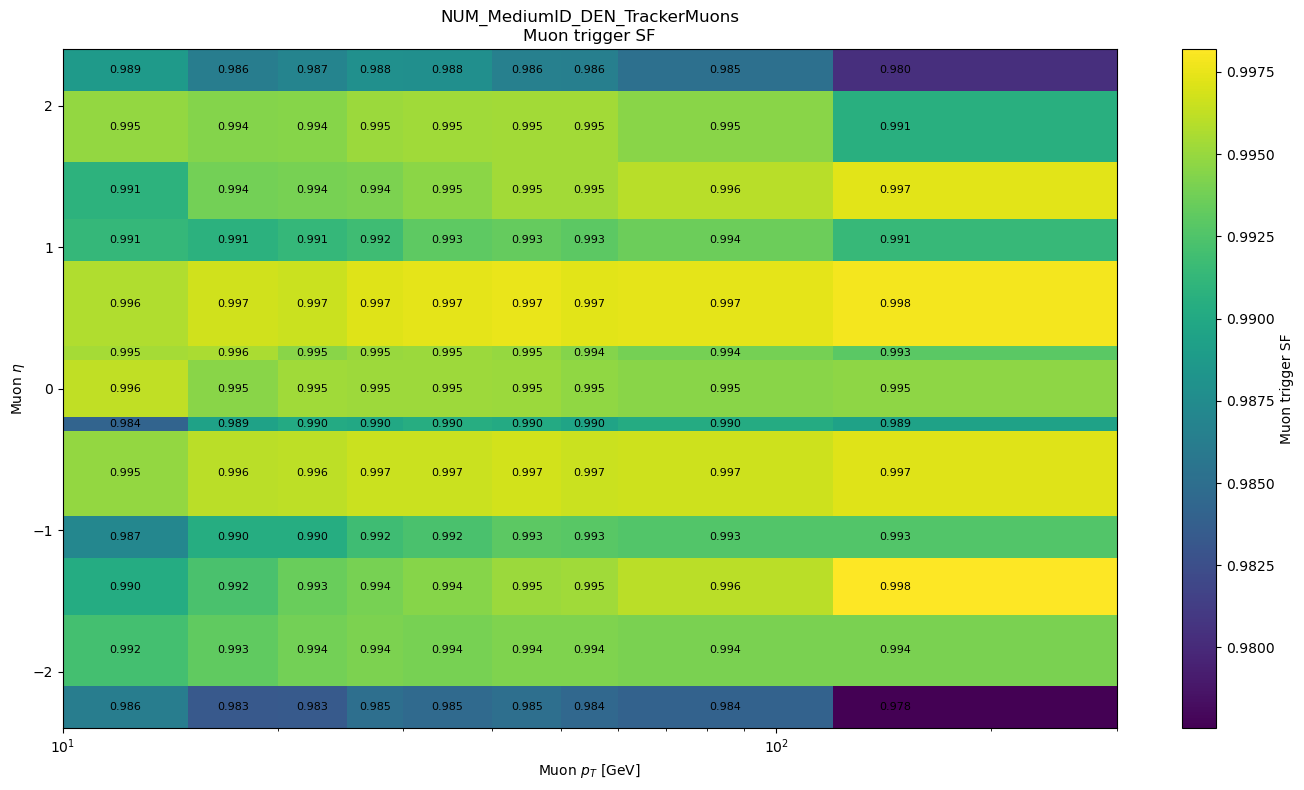

In [25]:
data_eff, _, _ = plot_muon_trigger(
    "muon_Z.json",
    "NUM_MediumID_DEN_TrackerMuons",
    key="nominal",
)

Correction : NUM_MediumPFIso_DEN_MediumID
Quantity   : nominal
Eta bins   : 13
pT bins    : 9
Range      : 0.880700694885474 to 1.0787688408782123


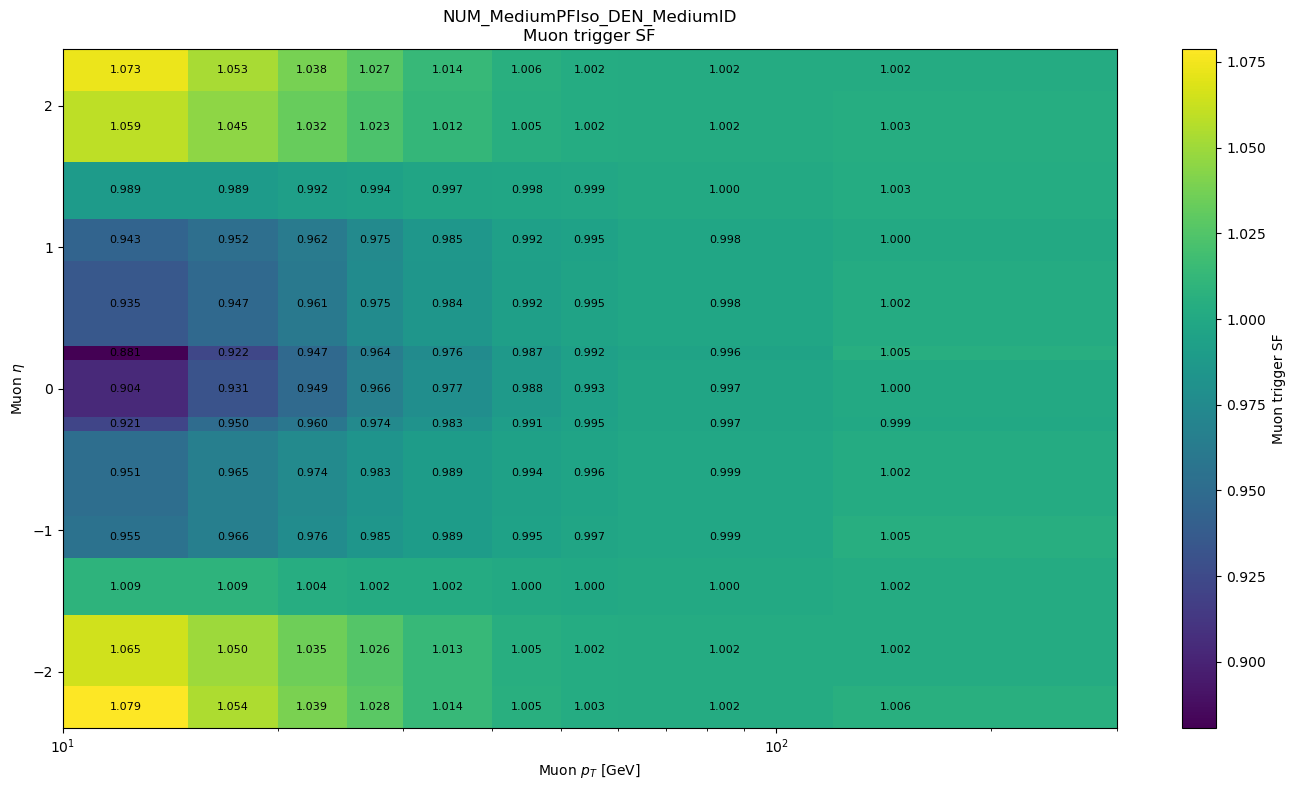

In [26]:
data_eff, _, _ = plot_muon_trigger(
    "muon_Z.json",
    "NUM_MediumPFIso_DEN_MediumID",
    key="nominal",
)

In [9]:
with open("/eos/user/b/bbapi/HiggsDNA_220526/HiggsDNA/higgs_dna/systematics/JSONs/MuonScaRe/2024.json", "r") as f:
    data = json.load(f)
print(data.keys())
for corr in data["corrections"]:
    print(corr["name"])
corr = next(
    c for c in data["corrections"]
    if c["name"] == "m_data"
)
print(corr["data"].keys())
print(corr["data"]["input"])

data_m = corr["data"]

print("nodetype:", data_m["nodetype"])
print("input:", data_m["input"])
print("flow:", data_m["flow"])

print("\nNumber of eta bins:", len(data_m["edges"]) - 1)
print("\nEta edges:")
print(data_m["edges"])

print("\nFirst few contents:")
for i, value in enumerate(data_m["content"][:10]):
    print(i, value)


dict_keys(['schema_version', 'description', 'corrections', 'compound_corrections'])
cb_params
poly_params
m_data
a_data
m_mc
a_mc
k_data
k_mc
RandomSmearing
dict_keys(['nodetype', 'input', 'edges', 'content', 'flow'])
eta
nodetype: binning
input: eta
flow: clamp

Number of eta bins: 8

Eta edges:
[-2.4, -2.1, -1.85, -0.4, 0.0, 0.4, 1.85, 2.1, 2.4]

First few contents:
0 {'nodetype': 'binning', 'input': 'phi', 'edges': [-3.2, -2.8, -2.4, -2.0, -1.6, -1.2, -0.8, -0.4, 0.0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2], 'content': [{'nodetype': 'category', 'input': 'variation', 'content': [{'key': 'nom', 'value': 0.9967881687885033}], 'default': 12345.0}, {'nodetype': 'category', 'input': 'variation', 'content': [{'key': 'nom', 'value': 0.9971757778720515}], 'default': 12345.0}, {'nodetype': 'category', 'input': 'variation', 'content': [{'key': 'nom', 'value': 0.996275387716908}], 'default': 12345.0}, {'nodetype': 'category', 'input': 'variation', 'content': [{'key': 'nom', 'value': 0.996772554

In [15]:
import json
import numpy as np
import matplotlib.pyplot as plt


def plot_correction_2d(data, correction_name, variation="nom"):
    """
    Plot a 2D correctionlib correction.

    Parameters
    ----------
    data : dict
        Loaded correctionlib JSON dictionary.

    correction_name : str
        Name of the correction, e.g. "m_data", "a_data", "m_mc".

    variation : str
        Variation to plot, usually "nom".
    """

    # ------------------------------------------------------------
    # Find correction
    # ------------------------------------------------------------
    corr = next(
        c for c in data["corrections"]
        if c["name"] == correction_name
    )

    node = corr["data"]

    # ------------------------------------------------------------
    # Check that this is eta -> phi binning
    # ------------------------------------------------------------
    if node.get("nodetype") != "binning":
        raise ValueError(
            f"{correction_name} is not a binning correction."
        )

    x_input = node["input"]
    x_edges = np.asarray(node["edges"])

    # Each x-bin should contain another binning
    first_content = node["content"][0]

    if first_content.get("nodetype") != "binning":
        raise ValueError(
            f"{correction_name} does not contain a second binning dimension."
        )

    y_input = first_content["input"]
    y_edges = np.asarray(first_content["edges"])

    # ------------------------------------------------------------
    # Extract values
    # ------------------------------------------------------------
    values = []

    for x_bin in node["content"]:

        if x_bin["nodetype"] != "binning":
            raise ValueError(
                f"Unexpected node type in {correction_name}: "
                f"{x_bin['nodetype']}"
            )

        row = []

        for y_bin in x_bin["content"]:

            if y_bin["nodetype"] != "category":
                raise ValueError(
                    f"Unexpected node type in {correction_name}: "
                    f"{y_bin['nodetype']}"
                )

            # Find requested variation
            value = None

            for item in y_bin["content"]:
                if item["key"] == variation:
                    value = item["value"]
                    break

            if value is None:
                value = y_bin["default"]

            row.append(value)

        values.append(row)

    values = np.asarray(values)

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(9, 6))

    mesh = ax.pcolormesh(
        y_edges,
        x_edges,
        values,
        shading="auto"
    )

    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label(correction_name)

    ax.set_xlabel(y_input)
    ax.set_ylabel(x_input)

    ax.set_title(
        f"{correction_name} ({variation})"
    )

    plt.tight_layout()
    plt.show()

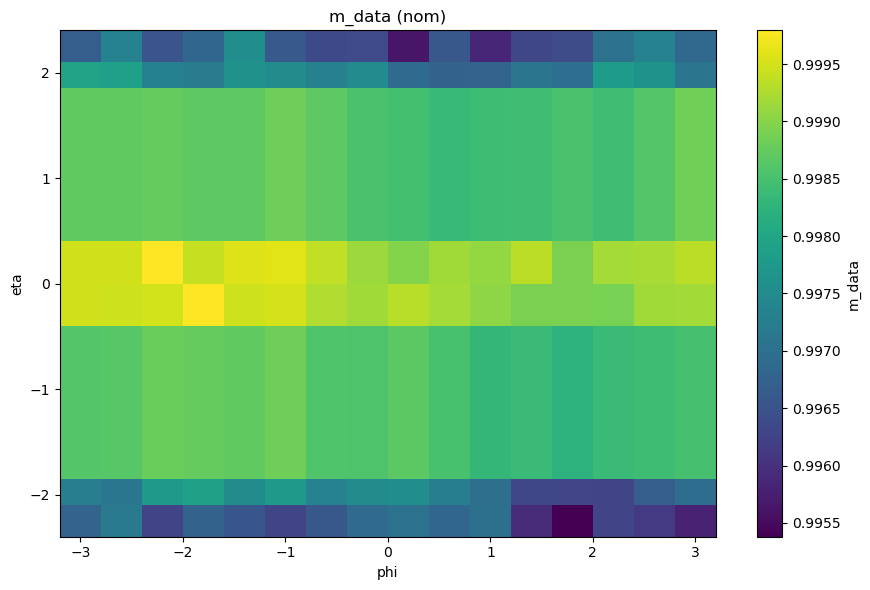

In [16]:
with open(
    "/eos/user/b/bbapi/HiggsDNA_220526/HiggsDNA/"
    "higgs_dna/systematics/JSONs/MuonScaRe/2024.json"
) as f:
    data = json.load(f)

plot_correction_2d(data, "m_data")

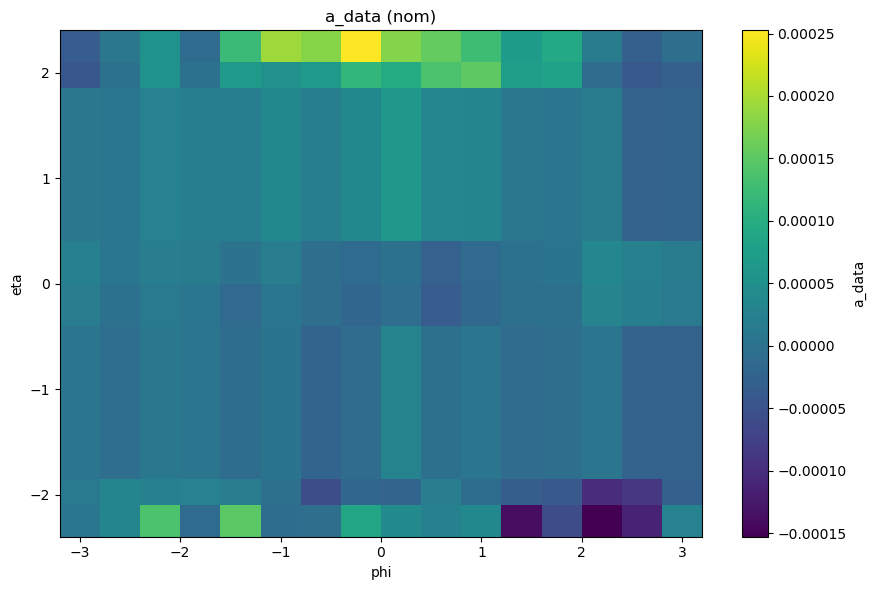

In [12]:
with open(
    "/eos/user/b/bbapi/HiggsDNA_220526/HiggsDNA/"
    "higgs_dna/systematics/JSONs/MuonScaRe/2024.json"
) as f:
    data = json.load(f)

plot_correction_2d(data, "a_data")

In [2]:
with open(
    "/eos/user/b/bbapi/HiggsDNA_220526/HiggsDNA/"
    "higgs_dna/systematics/JSONs/bTagEff/2024_Summer24/HtoAAtobbgg.json"
) as f:
    data = json.load(f)

In [3]:
data

{'schema_version': 2,
 'description': 'Correction set for b-tagging efficiencies',
 'corrections': [{'name': 'btagging_efficiencies',
   'description': 'Correction that contains the b-tagging efficiencies as a function of the process, the jet hadron flavour, transverse momentum and absolute eta.',
   'version': 1,
   'inputs': [{'name': 'process',
     'type': 'string',
     'description': 'Simulation process'},
    {'name': 'wp', 'type': 'string', 'description': 'B-tagging working point'},
    {'name': 'flav', 'type': 'int', 'description': 'Jet hadron flavour'},
    {'name': 'abseta', 'type': 'real', 'description': 'Jet absolute eta'},
    {'name': 'pt', 'type': 'real', 'description': 'Jet transverse momentum'}],
   'output': {'name': 'efficiency',
    'type': 'real',
    'description': 'B-tagging efficiency'},
   'data': {'nodetype': 'category',
    'input': 'process',
    'content': [{'key': 'DYGto2LG4_24SummerRun3',
      'value': {'nodetype': 'category',
       'input': 'wp',
    

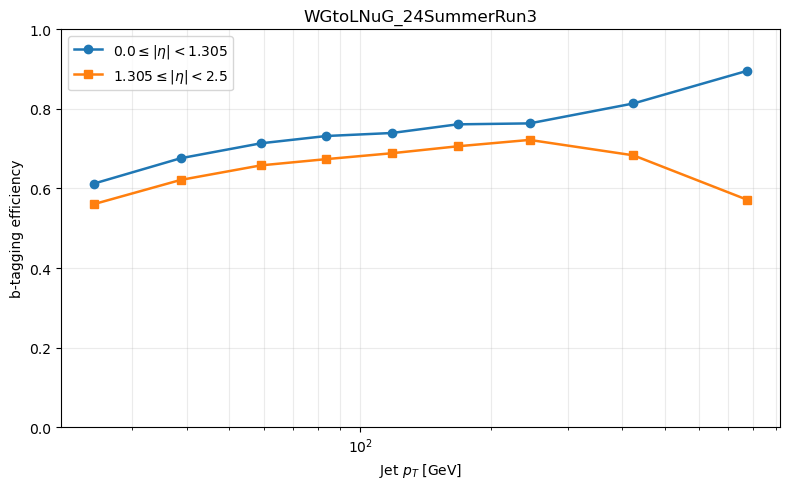

Saved: btag_efficiency_WGtoLNuG_flav5.png


In [8]:
import ast
import matplotlib.pyplot as plt
from pathlib import Path

corr = data["corrections"][0]
processes = corr["data"]["content"]

def get_efficiency(process_name, flav=5, eta_bin=0, wp="M"):
    """Return pT bin centers and efficiencies for one process/flavour/|eta| bin."""
    pnode = next(x["value"] for x in processes if x["key"] == process_name)
    wnode = next(x["value"] for x in pnode["content"] if x["key"] == wp)
    fnode = next(x["value"] for x in wnode["content"] if x["key"] == flav)
    
    eta_edges = fnode["edges"]
    pt_node = fnode["content"][eta_bin]
    pt_edges = pt_node["edges"]
    eff = pt_node["content"]
    
    # Values are defined in each pT bin, so use geometric bin centres.
    pt_centers = [(a*b)**0.5 for a, b in zip(pt_edges[:-1], pt_edges[1:])]
    eta_range = (eta_edges[eta_bin], eta_edges[eta_bin+1])
    return pt_centers, eff, eta_range

# Example: plot b-jet (flavour 5) efficiency for one process,
# separately for the two |eta| regions.
process_name = "WGtoLNuG_24SummerRun3"

fig, ax = plt.subplots(figsize=(8, 5))

for eta_bin, marker in [(0, "o"), (1, "s")]:
    pt, eff, eta_range = get_efficiency(process_name, flav=5, eta_bin=eta_bin)
    ax.plot(pt, eff, marker=marker, linewidth=1.8,
            label=fr"${eta_range[0]} \leq |\eta| < {eta_range[1]}$")

ax.set_xscale("log")
ax.set_xlabel(r"Jet $p_T$ [GeV]")
ax.set_ylabel("b-tagging efficiency")
ax.set_ylim(0, 1)
ax.set_title(process_name)
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()

out = "btag_efficiency_WGtoLNuG_flav5.png"
fig.savefig(out, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved: {out}")


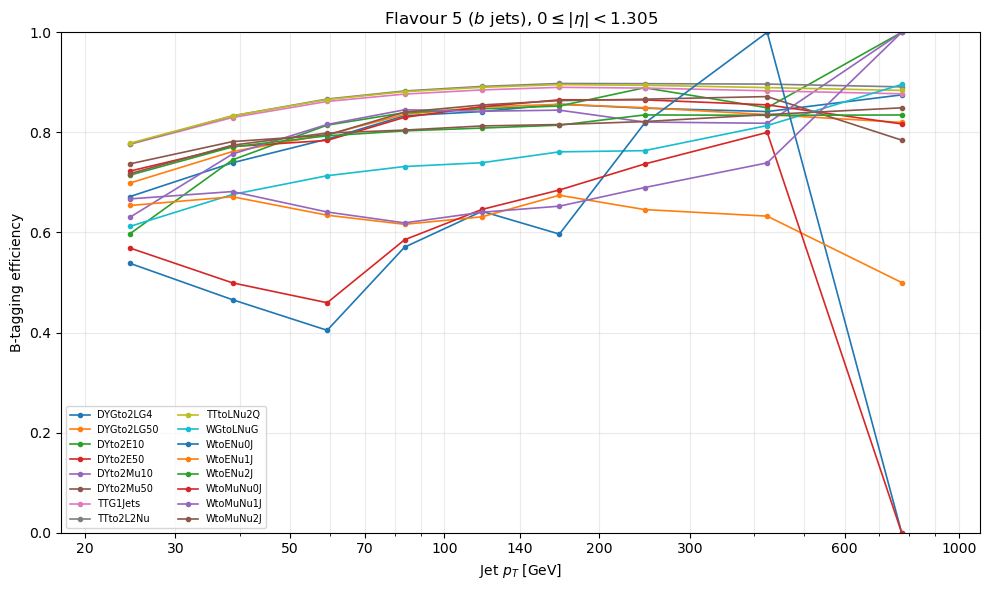

Created 16 individual process plots.
Folder: btag_efficiency_all_processes
Combined b-jet comparison: btag_efficiency_all_processes/all_processes_bjets_central.png


In [12]:
import ast
from pathlib import Path
import matplotlib.pyplot as plt

corr = data["corrections"][0]
process_nodes = corr["data"]["content"]

def extract(process_node, flav, eta_bin):
    wp_node = next(x["value"] for x in process_node["value"]["content"] if x["key"] == "M")
    flav_node = next(x["value"] for x in wp_node["content"] if x["key"] == flav)
    pt_node = flav_node["content"][eta_bin]
    edges, vals = pt_node["edges"], pt_node["content"]
    centers = [(a*b)**0.5 for a,b in zip(edges[:-1], edges[1:])]
    return centers, vals

out_dir = Path("btag_efficiency_all_processes/")
out_dir.mkdir(exist_ok=True)

flavs = {0: "light (0)", 4: "c (4)", 5: "b (5)"}
etas = [(0, "0 ≤ |η| < 1.305", "o"), (1, "1.305 ≤ |η| < 2.5", "s")]

for pnode in process_nodes:
    process = pnode["key"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)

    for ax, (flav, flabel) in zip(axes, flavs.items()):
        for eta_bin, label, marker in etas:
            pt, eff = extract(pnode, flav, eta_bin)
            ax.plot(pt, eff, marker=marker, linewidth=1.7, markersize=5, label=label)

        ax.set_title(f"Flavour {flabel}")
        ax.set_xscale("log")
        ax.set_xlim(18, 1100)

        ax.set_xticks([20, 30, 50, 70, 100, 140, 200, 300, 600, 1000])
        ax.set_xticklabels(["20", "30", "50", "70", "100", "140", "200", "300", "600", "1000"])
        ax.set_xlabel(r"Jet $p_T$ [GeV]")
        ax.set_ylim(0, 1)
        ax.grid(True, which="both", alpha=0.25)

    axes[0].set_ylabel("B-tagging efficiency")
    axes[0].legend(fontsize=8, title=r"$|\eta|$ range")
    fig.suptitle(process, fontsize=13)
    fig.tight_layout()

    fig.savefig(out_dir / f"{process}.png", dpi=180, bbox_inches="tight")
    plt.close(fig)

# Also make a combined comparison plot for b-jets, central eta.
fig, ax = plt.subplots(figsize=(10, 6))
for pnode in process_nodes:
    pt, eff = extract(pnode, 5, 0)
    ax.plot(pt, eff, marker="o", markersize=3, linewidth=1.2, label=pnode["key"].replace("_24SummerRun3",""))

ax.set_xscale("log")
ax.set_xlim(18, 1100)

ax.set_xticks([20, 30, 50, 70, 100, 140, 200, 300, 600, 1000])
ax.set_xticklabels(["20", "30", "50", "70", "100", "140", "200", "300", "600", "1000"])
ax.set_xlabel(r"Jet $p_T$ [GeV]")
ax.set_ylabel("B-tagging efficiency")
ax.set_ylim(0, 1)
ax.set_title(r"Flavour 5 ($b$ jets), $0 \leq |\eta| < 1.305$")
ax.grid(True, which="both", alpha=0.25)
ax.legend(fontsize=7, ncol=2)
fig.tight_layout()
combined = out_dir / "all_processes_bjets_central.png"
fig.savefig(combined, dpi=180, bbox_inches="tight")
plt.show()

print(f"Created {len(process_nodes)} individual process plots.")
print(f"Folder: {out_dir}")
print(f"Combined b-jet comparison: {combined}")


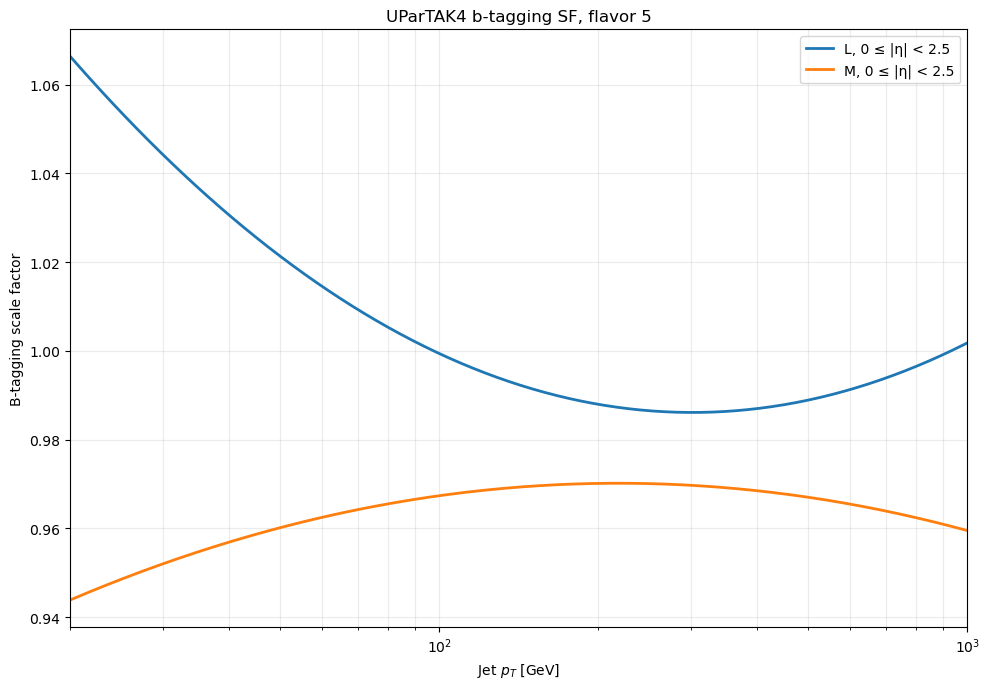

In [19]:
import json
import correctionlib
import numpy as np
import matplotlib.pyplot as plt

JSON_FILE = "/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Miscellaneous/btagging.json"
CORRECTION_NAME = "UParTAK4_comb"
SYSTEMATIC = "central"
WORKING_POINTS = ["L","M"]
FLAVOR = 5

cset = correctionlib.CorrectionSet.from_file(JSON_FILE)
corr = cset[CORRECTION_NAME]

with open(JSON_FILE) as f:
    data = json.load(f)

json_corr = next(c for c in data["corrections"] if c["name"] == CORRECTION_NAME)
systematic_node = next(x["value"] for x in json_corr["data"]["content"] if x["key"] == SYSTEMATIC)

fig, ax = plt.subplots(figsize=(10,7))

for wp in WORKING_POINTS:
    wp_node = next(x["value"] for x in systematic_node["content"] if x["key"] == wp)
    flavor_node = next(x["value"] for x in wp_node["content"] if x["key"] == FLAVOR)
    eta_edges = flavor_node["edges"]
    pt_node = flavor_node["content"][0]
    pt_edges = pt_node["edges"]
    pt = np.geomspace(pt_edges[0],pt_edges[-1],300)
    for i in range(len(eta_edges)-1):
        eta_min = eta_edges[i]
        eta_max = eta_edges[i+1]
        eta = 0.5*(eta_min+eta_max)
        sf = np.array([corr.evaluate(SYSTEMATIC,wp,FLAVOR,eta,x) for x in pt])
        ax.plot(pt,sf,linewidth=2,label=f"{wp}, {eta_min:g} ≤ |η| < {eta_max:g}")

ax.set_xscale("log")
ax.set_xlim(pt_edges[0],pt_edges[-1])
ax.set_xlabel(r"Jet $p_T$ [GeV]")
ax.set_ylabel("B-tagging scale factor")
ax.set_title(f"UParTAK4 b-tagging SF, flavor {FLAVOR}")
ax.grid(True,which="both",alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

In [23]:
import json
import correctionlib
import numpy as np
import matplotlib.pyplot as plt
import os

JSON_FILE = "/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Miscellaneous/btagging.json"
CORRECTION_NAME = "UParTAK4_comb"
OUTPUT_DIR = "/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Miscellaneous/btag_plots"

os.makedirs(OUTPUT_DIR,exist_ok=True)

cset = correctionlib.CorrectionSet.from_file(JSON_FILE)
corr = cset[CORRECTION_NAME]

with open(JSON_FILE) as f:
    data = json.load(f)

json_corr = next(c for c in data["corrections"] if c["name"] == CORRECTION_NAME)
systematic_nodes = json_corr["data"]["content"]

for systematic_entry in systematic_nodes:
    systematic = systematic_entry["key"]
    systematic_node = systematic_entry["value"]
    for wp_entry in systematic_node["content"]:
        wp = wp_entry["key"]
        wp_node = wp_entry["value"]
        for flavor_entry in wp_node["content"]:
            flavor = flavor_entry["key"]
            flavor_node = flavor_entry["value"]
            eta_edges = flavor_node["edges"]
            plt.figure(figsize=(10,7))
            for ieta in range(len(eta_edges)-1):
                eta_min = eta_edges[ieta]
                eta_max = eta_edges[ieta+1]
                pt_node = flavor_node["content"][ieta]
                pt_edges = pt_node["edges"]
                for ipt in range(len(pt_edges)-1):
                    pt_min = pt_edges[ipt]
                    pt_max = pt_edges[ipt+1]
                    pt_values = np.geomspace(pt_min,pt_max,50)
                    eta_value = 0.5*(eta_min+eta_max)
                    sf_values = np.array([corr.evaluate(systematic,wp,flavor,eta_value,pt) for pt in pt_values])
                    label = f"{wp}, {eta_min:g} ≤ |η| < {eta_max:g}" if ipt == 0 else None
                    plt.plot(pt_values,sf_values,label=label)
            plt.xscale("log")
            plt.xlabel(r"Jet $p_T$ [GeV]")
            plt.ylabel("B-tagging scale factor")
            plt.title(f"UParTAK4 b-tagging SF: {systematic}, flavor {flavor}")
            plt.grid(True,which="both",alpha=0.25)
            plt.legend()
            plt.tight_layout()
            output_file = os.path.join(OUTPUT_DIR,f"UParTAK4_{systematic}_{wp}_flavor{flavor}.png")
            plt.savefig(output_file,dpi=300,bbox_inches="tight")
            plt.close()